Grad-CAM for CNN visualization

# 1. Prepare the environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi -L

GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-b4201d88-77a7-ae4e-41a5-c4c319571b2e)


In [2]:
import sys
print( f"Python {sys.version}\n" )

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

import cv2 as cv
print( f"OpenCV {cv.__version__}\n" )

# https://keras.io/getting_started/
# The backend must be configured before importing Keras, and the backend cannot be changed after the package has been imported.
import os
os.environ["KERAS_BACKEND"] = "torch"  # "jax", "tensorflow"

import keras
print(f"Keras {keras.__version__}")
print(f"|- Keras backend = {keras.backend.backend()}")
print(f"|- Keras backend image data format = {keras.backend.image_data_format()}\n")

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]

NumPy 2.0.2

OpenCV 4.12.0

Keras 3.10.0
|- Keras backend = torch
|- Keras backend image data format = channels_last

PyTorch 2.8.0+cu126
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- CUDA GPU 0: NVIDIA A100-SXM4-40GB


# 2. Load the model to inspect

Be careful, when the last layer of the model includes any activation function (e.g., Softmax) and doesn't output raw prediction scores (=logits).
- Previously, we had to manually separate the softmax function from the last layer by creating a new output layer (without an activation function) and copying weights from the old one.
- Now, when loading a model, there is an option that allows us to include or exclude the activation function of the output layer.
> (https://keras.io/api/applications/vgg/) `classifier_activation` (default = 'softmax'):	A str or callable. The activation function to use on the "top" layer. Ignored unless include_top=True. Set classifier_activation=None to return the logits of the "top" layer. When loading pretrained weights, classifier_activation can only be None or "softmax".

In [3]:
# Load the pre-trained VGG16 model *without* the softmax activation in the output layer
base_model = keras.applications.VGG16(weights="imagenet", include_top=True, classifier_activation=None)

base_model.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

Check the activation function of the output layer (=the last layer):

In [4]:
print( base_model.layers[-1].activation )

<function linear at 0x7e55200bb2e0>


# 3. Adapt the base model

In [5]:
def alter_model_for_GradCAM( model, last_conv_layer_name ):
    # 1. Get the output from the last convolutional layer
    last_conv_output = model.get_layer( last_conv_layer_name ).output

    # 2. Create the new model with one additional output
    new_model = keras.Model( inputs=model.input, outputs=[model.output, last_conv_output] )

    return new_model

new_model = alter_model_for_GradCAM( base_model, 'block5_pool' )
new_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
new_model.outputs

[<KerasTensor shape=(None, 1000), dtype=float32, sparse=False, ragged=False, name=keras_tensor_22>,
 <KerasTensor shape=(None, 7, 7, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_18>]

In [7]:
new_model.output_names

['predictions', 'block5_pool']

# 4. Custom ImageNet's decode_predictions

In [8]:
def my_imagenet_decode_predictions( preds, top=5 ):
    """
    This function is adapted from https://github.com/keras-team/keras-applications/blob/master/keras_applications/imagenet_utils.py
    The adaptation is done so that ImageNet's class indices (0-999) are included in the function's outputs.

    Arguments:
        preds (numpy array): a batch of ImageNet's prediction outputs
        top (int): only decode 'top' classes with maximum scores

    Return a tuple of:
        Output[0]: a dict of { class_index:class_name } regarding the whole ImageNet dataset
        Output[1]: a 4D tuple of (class_index, class_name, class_description, score)
            Note that 'score' can be prediction values with or without the softmax activation, depending on the input 'preds'
    """
    if len(preds.shape) != 2 or preds.shape[1] != 1000:
        raise ValueError('`decode_predictions` expects '
                                 'a batch of predictions '
                                 '(i.e. a 2D array of shape (samples, 1000)). '
                                 'Found array with shape: ' + str(preds.shape))

    import json

    CLASS_INDEX_PATH = ('https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json')
    fpath = keras.utils.get_file( 'imagenet_class_index.json',
                                  CLASS_INDEX_PATH,
                                  cache_subdir='models',
                                  file_hash='c2c37ea517e94d9795004a39431a14cb' )
    with open(fpath) as f:
        CLASS_INDEX = json.load(f)
        CLASS_INDEX = dict( zip( [ int(i) for i in CLASS_INDEX.keys() ], CLASS_INDEX.values() ) )

    results = []
    for pred in preds:
        top_indices = pred.argsort()[-top:][::-1]
        result = [ (i,) + tuple(CLASS_INDEX[i]) + (pred[i],) for i in top_indices ]
        result.sort(key=lambda x: x[-1], reverse=True)
        results.append(result)

    return CLASS_INDEX, results

In [9]:
# Load two test images from Internet
!wget "https://unionlakepetservices.com/wp-content/uploads/2019/03/baby-3858285_1280-1080x675.jpg"
!wget "https://keras.io/img/examples/vision/grad_cam/grad_cam_12_0.jpg"

--2025-09-04 13:39:46--  https://unionlakepetservices.com/wp-content/uploads/2019/03/baby-3858285_1280-1080x675.jpg
Resolving unionlakepetservices.com (unionlakepetservices.com)... 35.185.94.56
Connecting to unionlakepetservices.com (unionlakepetservices.com)|35.185.94.56|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 83771 (82K) [image/jpeg]
Saving to: ‘baby-3858285_1280-1080x675.jpg’

baby-3858285_1280-1 100%[===================>]  81.81K  --.-KB/s    in 0.03s   

2025-09-04 13:39:46 (2.49 MB/s) - ‘baby-3858285_1280-1080x675.jpg’ saved [83771/83771]

--2025-09-04 13:39:46--  https://keras.io/img/examples/vision/grad_cam/grad_cam_12_0.jpg
Resolving keras.io (keras.io)... 18.160.225.112, 18.160.225.68, 18.160.225.121, ...
Connecting to keras.io (keras.io)|18.160.225.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72452 (71K) [image/jpeg]
Saving to: ‘grad_cam_12_0.jpg’

grad_cam_12_0.jpg   100%[===================>]  70.75K  --.-K

In [10]:
# Check files currently in the local disk
!ls

baby-3858285_1280-1080x675.jpg	grad_cam_12_0.jpg  sample_data


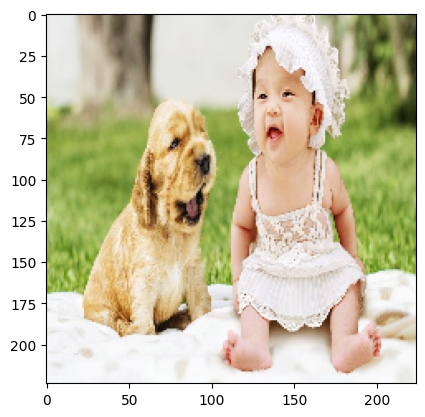

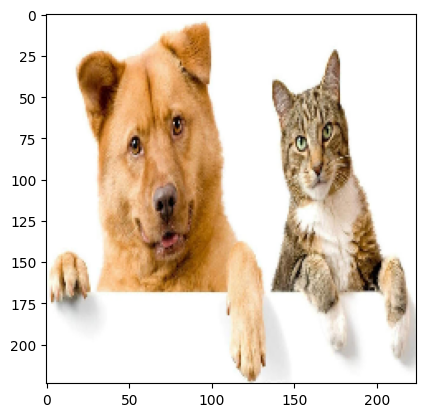

In [11]:
# Load images (from disk) as PIL.Image.Image
img_path1 = 'baby-3858285_1280-1080x675.jpg'
img_path2 = 'grad_cam_12_0.jpg'
img1 =  keras.preprocessing.image.load_img(img_path1, target_size=(224, 224))
img2 =  keras.preprocessing.image.load_img(img_path2, target_size=(224, 224))

# Convert PIL Images to NumPy ndarrays
img1 = keras.preprocessing.image.img_to_array(img1).astype(np.uint8)
img2 = keras.preprocessing.image.img_to_array(img2).astype(np.uint8)

# Display the NumPy images
plt.imshow(img1); plt.show()
plt.imshow(img2); plt.show()

In [12]:
# Preprocess the input images according to VGG16's requirements
img_preprocess1 = keras.applications.vgg16.preprocess_input( np.expand_dims(img1, axis=0) )
img_preprocess2 = keras.applications.vgg16.preprocess_input( np.expand_dims(img2, axis=0) )

Compare the original model and our new model to make sure that they produce identical results

In [13]:
# Original model
out_linear1 = base_model.predict( img_preprocess1 )
out_linear2 = base_model.predict( img_preprocess2 )

imagenet_dict, result1 = my_imagenet_decode_predictions( out_linear1, top=10 )
imagenet_dict, result2 = my_imagenet_decode_predictions( out_linear2, top=10 )
print( result1 )
print( result2 )

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 917ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[[(np.int64(219), 'n02102318', 'cocker_spaniel', np.float32(7.8858175)), (np.int64(207), 'n02099601', 'golden_retriever', np.float32(7.5638094)), (np.int64(578), 'n03450230', 'gown', np.float32(7.2273116)), (np.int64(601), 'n03534580', 'hoopskirt', np.float32(6.859944)), (np.int64(208), 'n02099712', 'Labrador_retriever', np.float32(6.8146567)), (np.int64(160), 'n02088094', 'Afghan_hound', np.float32(6.4784856)), (np.int64(216), 'n02101556', 'clumber', np.float32(6.283061)), (np.int64(434), 'n02808304', 'bath_towel', np.float32(6.259467)), (np.int64(929), 'n07615774', 'ice_lolly', np.float32(6.0593767)), (np.int64(529), 'n03188531', 'diaper', np.float32(5.8481174))]]
[[(np.int64(231), 'n02106030', 'collie', np.float32(8.142399)), (np.int64(253), 'n02110806', 'basenji', np.float32(7.8101325)), (np.int64(191), 'n02096051', 'Airedale', np.float32(7.6714325)), (np.int64(

In [14]:
# Our modified model
out_linear1, _ = new_model.predict( img_preprocess1 )
out_linear2, _ = new_model.predict( img_preprocess2 )

imagenet_dict, result1 = my_imagenet_decode_predictions( out_linear1, top=10 )
imagenet_dict, result2 = my_imagenet_decode_predictions( out_linear2, top=10 )
print( result1 )
print( result2 )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[[(np.int64(219), 'n02102318', 'cocker_spaniel', np.float32(7.8858175)), (np.int64(207), 'n02099601', 'golden_retriever', np.float32(7.5638094)), (np.int64(578), 'n03450230', 'gown', np.float32(7.2273116)), (np.int64(601), 'n03534580', 'hoopskirt', np.float32(6.859944)), (np.int64(208), 'n02099712', 'Labrador_retriever', np.float32(6.8146567)), (np.int64(160), 'n02088094', 'Afghan_hound', np.float32(6.4784856)), (np.int64(216), 'n02101556', 'clumber', np.float32(6.283061)), (np.int64(434), 'n02808304', 'bath_towel', np.float32(6.259467)), (np.int64(929), 'n07615774', 'ice_lolly', np.float32(6.0593767)), (np.int64(529), 'n03188531', 'diaper', np.float32(5.8481174))]]
[[(np.int64(231), 'n02106030', 'collie', np.float32(8.142399)), (np.int64(253), 'n02110806', 'basenji', np.float32(7.8101325)), (np.int64(191), 'n02096051', 'Airedale', np.float32(7.6714325)), (np.int64(184), 'n02093991', 'Irish_terrier', np.float32

# 5. Grad-CAM for CNN

In [15]:
def my_CNN_GradCAM( model, in_img, class_index, normalize=True ):
  '''
  A function to compute a GradCAM heatmap image

  Inputs:
    model (Keras's model): the target model that is specially prepared to be inspected by GradCAM
    in_img (NumPy array): an image to be inspected
    class_index (int, 0-999): an ImageNet's class index that we want to inspect its GradCAM heatmap
    normalize (bool): if True, normalize the resultant heatmap to [0,1]

  Outputs:
    An image of GradCAM heatmap
  '''
  # Convert from numpy array to torch's tensor
  in_img = torch.from_numpy( in_img.copy() ).float()

  # Move the model and images to the same device
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  in_img = in_img.to(device)
  model.to(device)

  # Set the model to inference mode
  model.eval()

  # Forward pass
  y_linear, last_conv_activation = model(in_img)
  one_class_score = y_linear[ ..., class_index ]

  # This is required to compute gradient w.r.t. to this non-leaf tensor
  # In PyTorch, .grad is only populated for tensors that have requires_grad=True and are leaf tensors.
  last_conv_activation.retain_grad()

  # Backward pass: Compute gradients on the last convolution layer
  model.zero_grad()
  one_class_score.backward(retain_graph=True)
  gradient = last_conv_activation.grad  # tensor: shape=(1,7,7,512)

  # Move data from GPU to CPU, and convert them from tensor to numpy
  gradient = gradient.cpu().numpy()
  last_conv_activation = last_conv_activation.detach().cpu().numpy()

  # Compute a vector of alphas by averaging each 2D gradient
  # Note that, one alpha value refers to a single weight value for a 2D feature map
  gradient = gradient.squeeze(axis=0)       # numpy: shape=(7,7,512)
  alpha = np.mean( gradient, axis=(0,1) )   # numpy: shape=(512,)

  # Compute the weighted-sum heatmap
  last_conv_activation = last_conv_activation.squeeze(axis=0)   # numpy: shape (1,7,7,512) => (7,7,512)
  heatmap = np.dot( last_conv_activation, alpha )   # numpy: shape=(7,7)

  # Don't highlight any pixels with negative gradients (= apply ReLU)
  heatmap = np.maximum( 0, heatmap )     # numpy: shape=(7,7)

  # Return the heatmap
  return heatmap / np.max(heatmap) if normalize else heatmap

 Test visualizing Grad-CAM for ImageNet classes with the 20 highest prediction scores

In [16]:
def visualize_GradCAM_topresult( model, original_img, input_img, logit_preds, top=100, heatmap_norm=True):
  '''
  A utility function that helps visualize the GradCAM results on top of the input image

  Inputs:
    model (Keras's model): the target model that is specially prepared to be inspected by GradCAM
    original_img (Numpy): an input image to be visualized
    input_img (Numpy): a preprocessed image to be fed to the model
    logit_preds (Numpy): an array of 1000 raw prediction scores (logits, non-softmax scores) regarding the 'input_img'
    top (int): how many class with top prediciton scores will be visualized
    heatmap_norm (bool): if True, normalize the heatmap to [0,1]
  '''
  # Get predictions with highest scores
  _ , top_results = my_imagenet_decode_predictions( logit_preds, top=top )

  # Extract 0-based class indices
  top_index = [ tp[0] for tp in top_results[0] ]

  # Visualize Grad-CAM for each class whose index is in 'top_index'
  for i,c in enumerate(top_index):
    heatmap = my_CNN_GradCAM(  model,         # the CNN model
                               input_img,     # input of the model
                               c,             # the 0-based index of the output class to compute and visualize GradCAM
                               heatmap_norm
                           )

    # Create the main figure
    fig = plt.figure(figsize=(15,5))
    class_desc = f"{imagenet_dict[c][-1]}, Top {i+1}/{top} with a logit score of {logit_preds[...,c].squeeze():.4f}"
    class_desc += f", normalized" if heatmap_norm else f", unnormalized"
    fig.suptitle( f"ImageNet class no. {c}/{len(imagenet_dict)-1} ({class_desc})" )

    # Subplot 1
    # Visualize the original heatmap
    ax = fig.add_subplot(1, 2, 1)
    ax.set_title( "Original Grad-CAM" )
    im = ax.imshow( heatmap, cmap='jet' )
    cbar = plt.colorbar( im, ax=ax )
    if heatmap_norm:
      cbar.set_ticks(np.arange(0.0, 1.0, 0.2))

    # Subplot 2
    # Visualize the heatmap overlaid on an input image
    ax = fig.add_subplot(1, 2, 2)
    ax.set_title( "Resized Grad-CAM on an input image" )
    ax.imshow( original_img )
    alpha = 0.6
    im = ax.imshow( cv.resize( heatmap, original_img.shape[:2] ), cmap='jet', alpha=alpha )
    cbar = plt.colorbar( im, ax=ax )
    if heatmap_norm:
      cbar.set_ticks(np.arange(0.0, 1.0, 0.2))

    # Show this figure
    plt.show()

In [17]:
# Test 'img1' with heatmap_norm=False
visualize_GradCAM_topresult( new_model, img1, img_preprocess1, out_linear1, top=20, heatmap_norm=False)

Output hidden; open in https://colab.research.google.com to view.

In [18]:
# Test 'img2' with heatmap_norm=True
visualize_GradCAM_topresult( new_model, img2, img_preprocess2, out_linear2, top=20, heatmap_norm=True)

Output hidden; open in https://colab.research.google.com to view.